# Agent的基本使用

## 1、Agent中模型的传入方式

### 1.1 传入字符串

In [10]:

from dotenv import load_dotenv
from langchain.agents import create_agent

load_dotenv(override=True)

agent = create_agent(
    model= "deepseek:deepseek-v4-flash"  # BaseChatModel
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


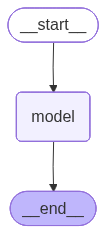

In [17]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 1.2 传入模型对象

In [16]:

from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
from langchain.agents import create_agent

load_dotenv(override=True)

model = init_chat_model(
    model="qwen3.7-plus",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    # extra_body={"enable_thinking": False},
)

agent = create_agent(
    model= model  #  BaseChatModel
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


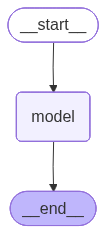

In [18]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 2、如何调用Agent

距离1：

In [20]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
from langchain.agents import create_agent
from rich import print as rprint

load_dotenv(override=True)

model = init_chat_model(
    model="qwen3.7-plus",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},
)

agent = create_agent(
    model = model
)

# 调用
response = agent.invoke({
    "messages":[
        {"role":"user", "content":"你好"}
    ]
})

rprint(response)

{
    'messages': [
        HumanMessage(
            content='你好',
            additional_kwargs={},
            response_metadata={},
            id='aa1eefe9-d7a3-4daa-95d8-6bf713924c54'
        ),
        AIMessage(
            content='你好！有什么我可以帮你的吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 8,
                    'prompt_tokens': 13,
                    'total_tokens': 21,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 13}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-d0f98895-1142-972f-aa54-e624e09ed53d',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64ca-9f0e-78d0-b77c-cf375dd61cd3-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 13,
                'output_tokens': 8,
                'total_tokens': 21,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

举例2：

In [21]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
from langchain.agents import create_agent
from rich import print as rprint

load_dotenv(override=True)

model = init_chat_model(
    model="qwen3.7-plus",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},
)

agent = create_agent(
    model = model
)

# 调用
response = agent.invoke({
    "messages":[
        {"role":"system", "content":"你是一个精通数学的老师，擅长以通俗易懂的方式讲解数学问题"},
        {"role":"user", "content":"100 + 20 * 3 = ？"}
    ]
})

rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个精通数学的老师，擅长以通俗易懂的方式讲解数学问题',
            additional_kwargs={},
            response_metadata={},
            id='d458f356-6913-45ae-b91f-b55769b4b6d7'
        ),
        HumanMessage(
            content='100 + 20 * 3 = ？',
            additional_kwargs={},
            response_metadata={},
            id='c92d7e7c-0442-4df4-840a-aea41ccf4f94'
        ),
        AIMessage(
            content='你好！我是你的数学老师。这道题看起来很简单，但里面藏着一个非常重要的数学规则，叫做**运算顺序**
（或者叫“先乘除，后加减”）。\n\n很多同学在刚接触时容易直接从左往右算，那样就会掉进陷阱里哦。我们来一步步拆解：\n\n#
## 第一步：识别运算符号\n算式里有两种运算：\n1. 加法 ($+$)\n2. 乘法 ($*$)\n\n### 
第二步：应用规则\n在数学中，**乘法的优先级高于加法**。这意味着我们要先算乘法部分，再算加法部分。\n\n*   ❌ 
**错误的做法**：先算 $100 + 20 = 120$，再算 $120 \\times 3 = 360$。（这是从左往右硬算，忽略了优先级）\n*   ✅ 
**正确的做法**：先算 $20 \\times 3$。\n\n### 第三步：具体计算\n1.  先算乘法：\n    $$20 \\times 3 = 60$$\n\n2.  
再把结果加到 100 上：\n    $$100 + 60 = 160$$\n\n### 最终答案\n$$100 + 20 \\times 3 = 160$$\n\n---\n\n**💡 
老师的小贴士：**\n你可以把乘法想象成“打包”。$20 \\times 3$ 意思是“3 包，每包 20 个苹果”，这 60 
个苹果是一个整体。然后你手里原本有 100 个苹果，再加上这 60 个，总共就是 160 个。这样理解是不是更直观了呢？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 375,
                    'prompt_tokens': 42,
                    'total_tokens': 417,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 42}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-f130aec7-603a-9a12-a645-eb14cd2c8292',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64ce-d161-73b0-9f8a-1e4bbb979c90-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 42,
                'output_tokens': 375,
                'total_tokens': 417,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

## 3、如何绑定工具并且调用工具

### 举例1：绑定一个自定义工具

In [25]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
from langchain.agents import create_agent
from langchain_core.tools import tool
from rich import print as rprint

load_dotenv(override=True)

model = init_chat_model(
    model="qwen3.7-plus",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},
)

# 定义工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取城市天气

    Args:
        city : 城市名称
    """
    return f"{city}天气晴朗，温度是15℃"

agent = create_agent(
    model = model,
    tools = [get_weather]
)

response = agent.invoke({
    "messages":[
        {"role":"system", "content":"你是一个查询城市天气的助手,如果用户问题与天气无关，你可以不回答"},
        {"role":"user", "content":"惠州仲恺高新区今天天气咋样呢？"}
    ]
})

rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个查询城市天气的助手,如果用户问题与天气无关，你可以不回答',
            additional_kwargs={},
            response_metadata={},
            id='16ff97f0-9fce-4809-beb1-61b97e3afc49'
        ),
        HumanMessage(
            content='惠州仲恺高新区今天天气咋样呢？',
            additional_kwargs={},
            response_metadata={},
            id='b63bd142-5c42-408d-bfd6-f670e33cd89d'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 25,
                    'prompt_tokens': 302,
                    'total_tokens': 327,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 302}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-8f7fd257-ef5d-9e68-8f49-e6aa6cd03df4',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f64ee-5a4f-7d70-ade4-94581f0a32b5-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '惠州'},
                    'id': 'call_dde29c3164e2413db087edfb',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 302,
                'output_tokens': 25,
                'total_tokens': 327,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='惠州天气晴朗，温度是15℃',
            name='get_weather',
            id='7b07cf25-2537-41ae-91f1-08358f65ae73',
            tool_call_id='call_dde29c3164e2413db087edfb'
        ),
        AIMessage(
            content='惠州今天天气晴朗，气温15℃。仲恺高新区作为惠州的一部分，天气情况基本一致。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 22,
                    'prompt_tokens': 354,
                    'total_tokens': 376,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 354}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-5bf694d7-e38e-91e1-a8cb-8bfb8d4d337a',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f64ee-5fb3-76c0-96fd-2bc95c2d4ec0-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 354,
                'output_tokens': 22,
                'total_tokens': 376,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

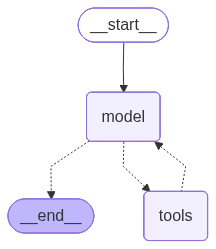

In [26]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 举例2：调用langchain内置工具

LangChain内置工具列表：https://docs.langchain.com/oss/python/integrations/tools


In [27]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
from langchain.agents import create_agent
from langchain_core.tools import tool
from rich import print as rprint
from langchain_tavily import TavilySearch

load_dotenv(override=True)

model = init_chat_model(
    model="qwen3.7-plus",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},
)

# 使用内置工具 这里我们需要先在tavily官网注册并获得API-KEY（每月有免费额度）：https://www.tavily.com/。
web_search = TavilySearch(
    max_results=2,
    tavily_api_key=os.getenv("TVILY_API_KEY"),
)

agent = create_agent(
    model = model,
    tools = [web_search]
)

response = agent.invoke({
    "messages":[
        {"role":"system", "content":"你是一个查询城市天气的助手,如果用户问题与天气无关，你可以不回答"},
        {"role":"user", "content":"惠州仲恺高新区今天天气咋样呢？"}
    ]
})

rprint(response)


{
    'messages': [
        SystemMessage(
            content='你是一个查询城市天气的助手,如果用户问题与天气无关，你可以不回答',
            additional_kwargs={},
            response_metadata={},
            id='5452e093-8d82-456f-974c-f281ce9f9e28'
        ),
        HumanMessage(
            content='惠州仲恺高新区今天天气咋样呢？',
            additional_kwargs={},
            response_metadata={},
            id='1c561e1e-d4fe-4065-a9c8-7e511902a3ab'
        ),
        AIMessage(
            content='我来帮你查询惠州仲恺高新区今天的天气情况。\n\n',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 67,
                    'prompt_tokens': 1838,
                    'total_tokens': 1905,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 1838}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-fa5a6683-01f1-9f39-9a55-35f15aa9b3ad',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f6521-a66c-7f11-9ac5-a6ef88359c8f-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {'query': '惠州仲恺高新区今天天气预报', 'search_depth': 'basic', 'topic': 'general'},
                    'id': 'call_5fbe649ef5a445838797411a',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1838,
                'output_tokens': 67,
                'total_tokens': 1905,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"query": "惠州仲恺高新区今天天气预报", "follow_up_questions": null, "answer": null, "images":
[], "results": [{"url": 
"https://www.douyin.com/search/%E4%BB%B2%E6%81%BA%E5%AE%9E%E6%97%B6%E5%A4%A9%E6%B0%94%E9%A2%84%E6%8A%A5", "title": 
"仲恺实时天气预报", "content": "天气预报|冷空气马上到!惠州局地将有强对流天气#惠州天气#阵雨 
视频来源：惠城发布，如有侵权请联系我们删除。 ... 惠州天气预报，最高气温27 度，最低气温22 。26，3，28。Read more", 
"score": 0.79254496, "raw_content": null}, {"url": "https://www.weather.com.cn/weather/101280301.shtml", "title": 
"惠州天气预报,惠州7天天气预报,惠州15天天气预报,惠州天气查询", "content": "首页 预报 预警 雷达 云图 天气地图 
专业产品 资讯 视频 节气. 台风路径 空间天气 图片 专题 环境 旅游 碳中和 气象科普 一带一路 产创平台. :   北京 上海 
成都 杭州 南京 天津 深圳 重庆 西安 广州 青岛 武汉. :   故宫 阳朔漓江 龙门石窟 野三坡 颐和园 九寨沟 东方明珠 
凤凰古城 秦始皇陵 桃花源. :   佘山 春城湖畔 华彬庄园 观澜湖 依必朗 旭宝 博鳌 玉龙雪山 番禺南沙 东方明珠. :   曼谷 
东京 首尔 吉隆坡 新加坡 巴黎 罗马 伦敦 雅典 柏林 纽约 温哥华 墨西哥城 哈瓦那 圣何塞 巴西利亚 布宜诺斯艾利斯 
圣地亚哥 利马 基多 悉尼 墨尔本 惠灵顿 奥克兰 苏瓦 开罗 内罗毕 开普敦 维多利亚 拉巴特. :   
\u200b\u200b\u200b广东粤西等局地今天有大暴雨 明后天降雨减弱粤东需防高温  中国天气网 2026-07-08 11:05. :   
超强台风“巴威”向台湾岛东北部沿海靠近 明起强度逐渐减弱  中国天气网 2026-07-08 10:48. :   吉林未来三天降雨连连 
部分地区有暴雨并伴雷暴大风或冰雹  中国天气网 2026-07-08 10:37. :   
强对流天气蓝色预警：京津冀等部分地区将有10级以上雷暴大风  中国天气网 2026-07-08 10:15. :   
暴雨预警：广东广西等10余省区部分地区有大到暴雨 局地大暴雨  中国天气网 2026-07-08 10:05. # 周边地区 *|* 周边景点 
*2026-07-08 11:30更新*. # 高清图集. 
今明天（7月8日至9日），我国强降雨范围将缩减，但广西、广东部分地区仍有明显降雨。同时，华北、黄淮等地高温天气发展增多
，多地高温持久。. ## “美莎克”残余环流深入内陆 南北方高温发展局地可达39℃. 
今天（7月7日），“美莎克”残余环流将深入内陆，给江苏、安徽、山东等多地带来强降雨，广西、广东多地强降雨。同时，南北方
多地高温天气发展。. 
今天（7月6日）早晨，台风“美莎克”进一步减弱为热带低压，广西、贵州、湖南等地仍有强降雨。同时，我国南北方多地将现高温
天气。. 
未来三天（7月5日至7日），华南至长江中下游一带强降雨持续，广西、贵州、湖南等地需警惕暴雨致灾；华北、黄淮等地高温天气
将逐渐缩减，热意有所缓和。. ## 台风“美莎克”携强降雨持续影响华南 北方高温范围广泛. 
受“美莎克”影响，未来三天（7月4日至6日），华南沿海等地雨势猛烈，局地或遭遇极端降雨；北方高温范围广泛，新疆、甘肃等地
酷热程度同期罕见。. 
随着台风靠近我国，今天（7月3日）起华南一带降雨将增多增强，长江中下游等地仍有强降雨，同时北方多地正在经历今年以来最
大范围的高温天气过程。. 
未来3天，云贵高原至江南中北部一带强降雨仍将持续，多地有暴雨、大暴雨，华北、东北的强对流天气也依然频繁。同时，未来三
天我国多地热意增强。. 
未来三天，我国强降雨会集中在云贵高原至江南一带，同时华北、东北等地也将频遭强对流。在西北、华北南部、黄淮、华南等地
，高温天气将逐渐发展。. 
今天起，南方新一轮强降雨来袭，长江中下游一带以及贵州、广西、云南等地需警惕暴雨致灾，同时东北、华北一带仍将维持多雨
格局。. 
今天（6月27日），南方降降雨主要集中在华南和西南地区，雨势较前期有所减弱。明天起，南方主雨带东段将北抬至江南北部，需
注意防范。. 
今天（6月27日），南方降雨将减弱，华南等地部分地区有大到暴雨。明后天，南方主雨带将北抬。在北方，华北、东北等地未来三
天多

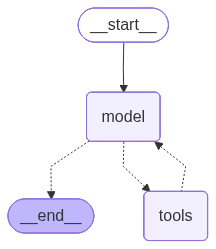

In [29]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 举例3：绑定多个工具，并且调用

In [28]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
from langchain.agents import create_agent
from langchain_core.tools import tool
from rich import print as rprint

load_dotenv(override=True)

model = init_chat_model(
    model="qwen3.7-plus",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL"),
    extra_body={"enable_thinking": False},
)

# 定义工具
@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    获取城市天气

    Args:
        city : 城市名称
    """
    return f"{city}天气晴朗，温度是15℃"

@tool(parse_docstring=True)
def get_news():
    """
    新闻查询工具
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。"

agent = create_agent(
    model = model,
    tools = [get_weather, get_news]
)

response = agent.invoke({
    "messages":[
        {"role":"user", "content":"惠州仲恺高新区今天天气咋样呢？今天有什么新闻？"}
    ]
})

rprint(response)

{
    'messages': [
        HumanMessage(
            content='惠州仲恺高新区今天天气咋样呢？今天有什么新闻？',
            additional_kwargs={},
            response_metadata={},
            id='056db303-a43c-4c26-a347-6a77745aa3e7'
        ),
        AIMessage(
            content='我来帮您查询惠州仲恺高新区的天气和今天的新闻。\n\n',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 52,
                    'prompt_tokens': 327,
                    'total_tokens': 379,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 327}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-04622b4a-1bcc-9060-b61a-2cfdfddf5f55',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f6529-618f-7b81-823c-aaf9b91263df-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '惠州'},
                    'id': 'call_76010e0de1da4f7792fd0eeb',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_d12aa0fd161d4a339129b45f', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 327,
                'output_tokens': 52,
                'total_tokens': 379,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='惠州天气晴朗，温度是15℃',
            name='get_weather',
            id='97608df5-a570-4283-8d2a-6b373ca8b956',
            tool_call_id='call_76010e0de1da4f7792fd0eeb'
        ),
        ToolMessage(
            content='近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍
上涨，旧手机成“香饽饽”。',
            name='get_news',
            id='b7fb3e1f-2026-43f9-a6b8-e6e459b8b4c2',
            tool_call_id='call_d12aa0fd161d4a339129b45f'
        ),
        AIMessage(
            content='根据查询结果：\n\n**惠州仲恺高新区今天天气：**\n- 天气晴朗\n- 
温度：15℃\n\n**今天的新闻：**\n近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来"火热潮"，回
收价格普遍上涨，旧手机成"香饽饽"。\n\n今天天气不错，晴朗舒适，15℃的温度也比较宜人。如果您需要更详细的天气预报或其他
新闻信息，请告诉我！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 100,
                    'prompt_tokens': 446,
                    'total_tokens': 546,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 446}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-26792702-0dca-9b9b-ad9e-044b3bf46d24',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f6529-6854-7631-8400-f15fb3460958-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 446,
                'output_tokens': 100,
                'total_tokens': 546,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        )
    ]
}

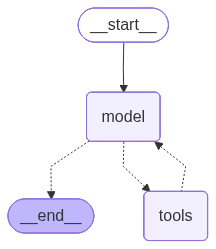

In [30]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 4、重试机制

Agent可以在工具调用结果不满足要求时，自主重试。

举例：

In [32]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from rich import print as rprint

load_dotenv(override=True)

flag = 0

@tool
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    global flag
    flag += 1
    if flag < 3:
        # raise Exception("暂时无法访问")
        return "TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"
    return f"{city}今天天气挺好"

messages = [
    SystemMessage("""
    你是一个天气助手。
    当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，
    说明是临时故障，不要立即放弃；
    你应再次调用同一个工具，最多重试 3 次。
    如果 3 次后仍失败，再向用户说明服务暂时不可用。
    """),
    HumanMessage("你好，陈江今天的天气如何？")
]

agent = create_agent(model, tools=[get_weather])
response = agent.invoke({"messages": messages})

rprint(response)

# for msg in response["messages"]:
#     msg.pretty_print()

{
    'messages': [
        SystemMessage(
            content="\n    你是一个天气助手。\n    当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，\n    
说明是临时故障，不要立即放弃；\n    你应再次调用同一个工具，最多重试 3 次。\n    如果 3 
次后仍失败，再向用户说明服务暂时不可用。\n    ",
            additional_kwargs={},
            response_metadata={},
            id='9a47a1a2-7193-4c63-9c7a-160995129382'
        ),
        HumanMessage(
            content='你好，陈江今天的天气如何？',
            additional_kwargs={},
            response_metadata={},
            id='89d566c7-687e-459e-ae92-328b427d2cad'
        ),
        AIMessage(
            content='我来查询陈江今天的天气情况。\n\n',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 35,
                    'prompt_tokens': 358,
                    'total_tokens': 393,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 358}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-e92cdf5b-b111-9f19-a363-6788580bfc92',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f657b-4bd2-7563-b82f-fe9ccd57e79a-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '陈江'},
                    'id': 'call_77499a0e70584c91ba4a4ce3',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 358,
                'output_tokens': 35,
                'total_tokens': 393,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试',
            name='get_weather',
            id='90262247-e3f6-4bce-ac99-bd809f28dc35',
            tool_call_id='call_77499a0e70584c91ba4a4ce3'
        ),
        AIMessage(
            content='看起来天气服务暂时不可用，让我重试一次。\n\n',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 38,
                    'prompt_tokens': 425,
                    'total_tokens': 463,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 425}
                },
                'model_provider': 'openai',
                'model_name': 'qwen3.7-plus',
                'system_fingerprint': None,
                'id': 'chatcmpl-dcc6f50f-002d-9cb2-b0ec-f9775442954e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f657b-5140-7833-8e26-6f24a55babdc-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '陈江'},
                    'id': 'call_eba240fac2e54a2a853791de',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 425,
                'output_tokens': 38,
                'total_tokens': 463,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试',
            name='get_weather',
            id='2334fd91-6366-4cd7-b47d-2b45ff89d5c2',
            tool_call_id='call_eba240fac2e54a2a853791de'
        ),
        AIMessage(
            content='让我再重试一次。\n\n',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {

## 5、限制工具调用次数

举例：

In [ ]:
# 注意：这是高级用法，后续会详细学习
config = {
    "recursion_limit": 5  # 最多 5 步
}
response = agent.invoke(input, config=config)
